***Ejercicio 1: Construcción de una Red Neuronal LSTM con Keras***

**Objetivo:**

En este ejercicio, aprenderás a implementar una red neuronal de tipo LSTM (Long Short-Term Memory) utilizando la librería Keras. Las redes LSTM son un tipo de red neuronal recurrente (RNN) especialmente adecuada para problemas de predicción de secuencias, como series temporales o procesamiento de texto. El objetivo es construir un modelo LSTM para una tarea sencilla de predicción y evaluar su rendimiento.

**Descripción de la Tarea:**

Realizarás los siguientes pasos:
1. Preprocesar un conjunto de datos de series temporales (como precios de acciones, datos de temperatura u otra secuencia numérica).
2. Crear un modelo LSTM utilizando Keras.
3. Entrenar el modelo con los datos de entrenamiento.
4. Evaluar el rendimiento del modelo en los datos de prueba.
5. Visualizar la pérdida a lo largo de las epocs y realizar predicciones.

Pasos:
- Paso 1: Importar las librerías necesarias y cargar el conjunto de datos.
- Paso 2: Preprocesar los datos: Normalizarlos y dividirlos en conjuntos de entrenamiento y prueba.
- Paso 3: Reestructurar los datos al formato de entrada requerido para LSTM: [muestras, pasos de tiempo, características].
- Paso 4: Definir un modelo LSTM utilizando la clase Sequential de Keras.
- Paso 5: Compilar el modelo con una función de pérdida y un optimizador adecuado.
- Paso 6: Entrenar el modelo con los datos de entrenamiento.
- Paso 7: Evaluar el rendimiento del modelo y visualizar los resultados.

Conjunto de Datos:
Puedes usar cualquier conjunto de datos de series temporales para este ejercicio. Un conjunto de datos sencillo de temperatura, precios de acciones u otra secuencia numérica puede cargarse utilizando
librerías como Pandas. Para simplicidad, en este ejercicio supondremos que estás usando un conjunto de datos sintético de series temporales.

**Entregables Esperados:**
1. Un modelo LSTM completamente implementado utilizando Keras.
2. Un gráfico que muestre la pérdida de entrenamiento y validación a lo largo del tiempo.
3. Una comparación de los valores predichos frente a los valores reales en el conjunto de prueba.

In [1]:
# Importando las librerias necesarias.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# librerias genéricas
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# librerias ML
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Configuración y reproducibilidad.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Generación de datos sintéticos: Tendencia con estacionalidad y ruido.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def generate_trend_seasonal_series(n_points = 2000, season_length = 50):
  """
  Genera una serie con tendencia, componente estacional y ruido.
  * n_points: Número de observaciones en la serie.
  * season_length: Período de la estacionalidad.
  """

  t = np.arange(n_points)

  # Tendencia lineal
  #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  trend = 0.002 * t

  # Estacionalidad (seno con período definido)
  #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  seasonal = 0.5 * np.sin(2 * np.pi * t / season_length)

  # Ruido Gaussiano
  #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  noise = np.random.normal(loc = 0.0, scale = 0.05, size = n_points)

  # Serie con tendencia, componente estacional y ruido.
  #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  series = trend + seasonal + noise

  return pd.DataFrame({"value": series})
#

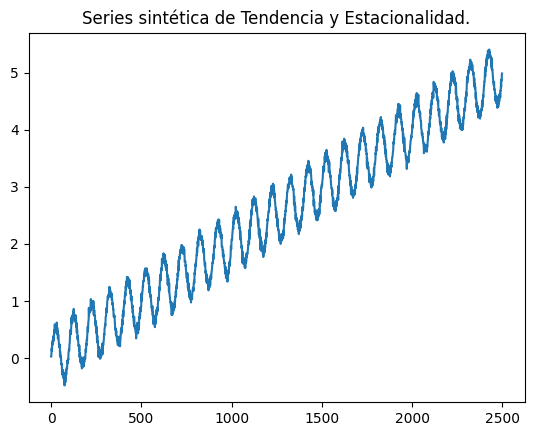

In [4]:
# Implementando función de datos sintéticos.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df_datos_sinteticos = generate_trend_seasonal_series(n_points = 2500, season_length = 100)
df_datos_sinteticos['value'].plot(title = "Series sintética de Tendencia y Estacionalidad.")
plt.show()
#
#


In [5]:
# Función de ventaneo para LSTM (período de tiempo ~ window_size)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def create_sequences(values, window_size = 60, horizon = 1):
  """
  values: array (n_samples)
  window_size: pasos de tiempo hacia atrás para predecir.
  horizon: pasos a futuro para predecir. (estamos utilizando 1-step ahead)
  """
  X, y = [],[]
  for i in range(len(values) - window_size - horizon + 1):
    X.append(values[i : i + window_size])
    y.append(values[i + window_size : i + window_size + horizon])
  X = np.array(X)
  y = np.array(y).reshape(-1, horizon)
  return X,y

In [6]:
# Preprocesamiento y Reestructuración de datos: Escalado de datos y división a subconjuntos de train y test.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
df_datos_sinteticos_scaled = scaler.fit_transform(df_datos_sinteticos[['value']].values).flatten()

WINDOW_SIZE = 60
HORIZON = 1

X, y = create_sequences(df_datos_sinteticos_scaled, WINDOW_SIZE, HORIZON)

# Formato LSTM: (Muestras, Pasos de tiempo, Características = 1)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
X = X.reshape((X.shape[0], X.shape[1], 1))

# División de set de datos: 80% train, 20% test.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
split_index = int(0.80 * len(X))

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

# Conjunto de validación desde el final del train (temporalidad).
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Definir la fracción de validación en 10%
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
validation_fraction = 0.1
# Calculando el tamaño de la muestra de validación en base al tamaño del set de datos.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
validation_size = int((len(X_train) * validation_fraction))
# Asignando el tamaño de validación tomando como base el set training.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
X_validation, y_validation = X_train[-validation_size:], y_train[-validation_size:]
# Calculando el set de datos training final para X e y.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
X_train_final, y_train_final = X_train[:validation_size], y_train[:validation_size]

In [7]:
# Definición de modelo LSTM.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
lstm_model = Sequential(
    [
      # Primer capa LSTM con 64 redes neuronales.
      #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
      Dropout(0.2),
      # Segunda capa LSTM con 32 redes neuronales.
      #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      LSTM(32),
      Dense(16, activation='relu'),
      # Salida 1-step ahead (lineal)
      #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      Dense(HORIZON)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compilar modelo LSTM.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
lstm_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = 'mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Entrenamiento de modelo LSTM.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Definiendo variable early_stopping a ser utilizada para configuración de entrenamiento de modelo.
early_stopping = EarlyStopping(
                                monitor='val_loss',
                                patience=10,
                                restore_best_weights=True
                              )

# Ejecutando el entrenamiento del modelo lstm_model.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
history = lstm_model.fit(
                          X_train_final, y_train_final,
                          validation_data=(X_validation, y_validation),
                          epochs=100,
                          batch_size=32,
                          callbacks=[early_stopping],
                          verbose=1
                        )

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.0119 - mae: 0.0910 - val_loss: 0.0315 - val_mae: 0.1732
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0035 - mae: 0.0471 - val_loss: 0.1188 - val_mae: 0.3425
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0028 - mae: 0.0447 - val_loss: 0.0847 - val_mae: 0.2889
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0015 - mae: 0.0336 - val_loss: 0.0302 - val_mae: 0.1708
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0013 - mae: 0.0309 - val_loss: 0.0337 - val_mae: 0.1814
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0011 - mae: 0.0281 - val_loss: 0.0164 - val_mae: 0.1253
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 7.6015e-04 - mae: 0.0238 - val_loss: 0.0036 - val_mae: 0.0553
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 6.3292e-04 - mae: 0.0216 - val_loss: 0.0046 - val_mae: 0.0642
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 5.179

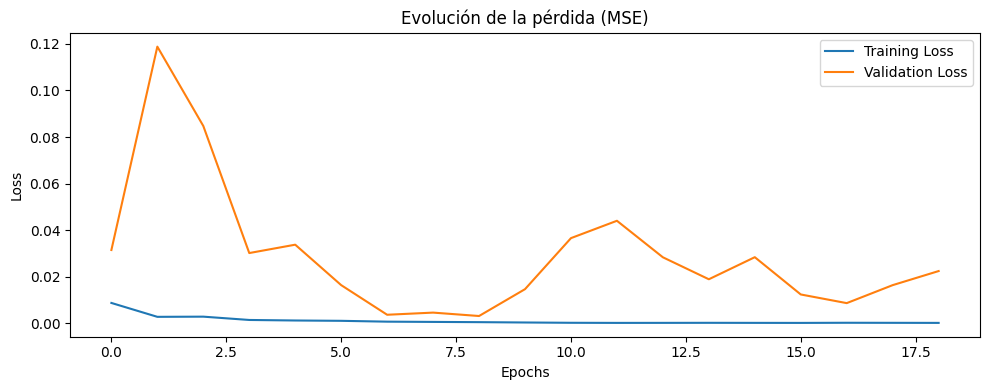

In [10]:
# Visualización de resultados para modelo LSTM.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Gráficos de pérdida.
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución de la pérdida (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Ejecutar predicciones de modelo LSTM con set de datos de prueba. (Evaluación de modelo)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Predicciones en test
y_pred = lstm_model.predict(X_test)

# Como hemos aplicado scaler sobre la serie de datos original, vamos a realizar el desajuste de la escala para comparación en valores originales.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
y_test_inversa = scaler.inverse_transform(y_test)
y_pred_inversa = scaler.inverse_transform(y_pred)

# Cálculo de métricas de error en base a variables invertidas.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
mae = mean_absolute_error(y_test_inversa, y_pred_inversa)
rmse = np.sqrt(mean_squared_error(y_test_inversa, y_pred_inversa))

print(f"MAE  (test): {mae:.4f}")
print(f"RMSE (test): {rmse:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
MAE  (test): 0.3638
RMSE (test): 0.3807


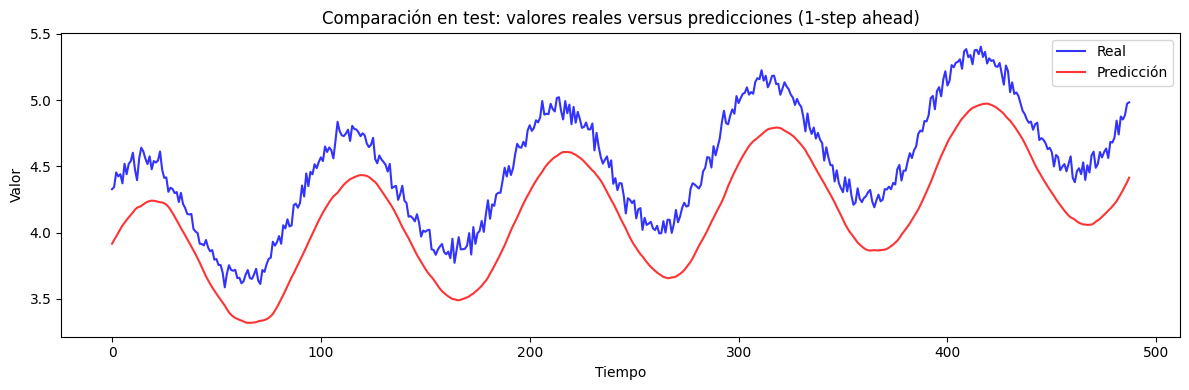

In [12]:
# Visualización de datos: Real vs Predicho.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(y_test_inversa, label='Real', alpha = 0.8, color='blue')
plt.plot(y_pred_inversa, label='Predicción', alpha = 0.8, color='red')
plt.title('Comparación en test: valores reales versus predicciones (1-step ahead)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()